Problem \
Use the Crank-Nicolson method to solve the following partial differential equation

$$
\frac{\partial u}{\partial t} - \frac{\partial^{\ 2} u}{\partial x^{2}} = 0, 0 < x < 2, 0 < t\\
u(0,t) = u(2,t) = 0, 0 < t\\
u(x,0) = sin\frac{\pi}{2}x, 0 \leq x \leq 2
$$

The exact solution of this poblem is

$$
u(x,t) = e^{-(\frac{\pi^{2}}{4})t}sin\frac{\pi}{2}x
$$

* Use a table to show the comparison between your approxiamtion and exact solutions.
* Plot the approximation solution $ u(x,t) $.

# 以下是作業的解答，但還不是最終解答，這是強調Crank-Nicolson method部分的程式碼，先確認我的程式碼是沒有問題的

Comparison at time T=1: 
x 	Approximation 	Exact
0.0	0.00000000	0.00000000
0.2	0.02673838	0.02620618
0.4	0.05085942	0.04984711
0.6	0.07000199	0.06860866
0.8	0.08229227	0.08065432
1.0	0.08652721	0.08480497
1.2	0.08229227	0.08065432
1.4	0.07000199	0.06860866
1.6	0.05085942	0.04984711
1.8	0.02673838	0.02620618
2.0	0.00000000	0.00000000


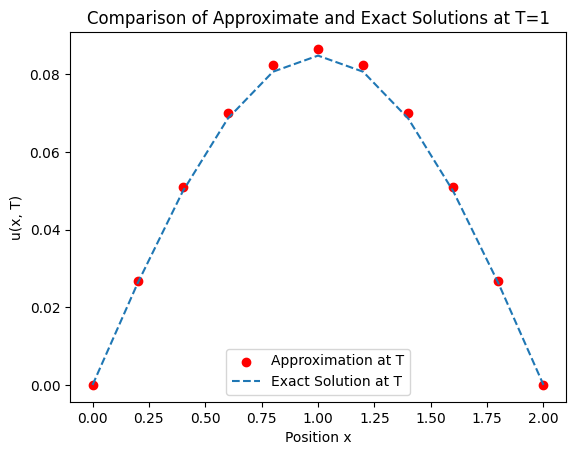

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 參數設定
L = 2          # 端點
T = 1          # maximum time
m = 10         # 要將Ｌ的切分數
N = 100        # 要將時間的切分數
h = L / m      # Ｌ間距
k = T / N      # 時間間距
alpha = 1      # constant
lambda1 = alpha**2 * k / h**2

# 初始條件
u_cn = np.zeros((m+1, N+1))
u_cn[:, 0] = np.sin(np.pi / 2 * np.linspace(0, L, m+1))

# 建立矩陣Ａ
diagonal = np.ones(m-1) * (1 + lambda1)
off_diagonal = np.ones(m-2) * (-lambda1 / 2)
A = np.diag(off_diagonal, -1) + np.diag(diagonal) + np.diag(off_diagonal, 1)

# Time-stepping loop
for n in range(1, N+1):
    # 用邊界條件 跟上一個解 計算向量Ｂ
    B = u_cn[0:m-1, n-1] * (lambda1 / 2) + u_cn[1:m, n-1] * (1 - lambda1) + u_cn[2:m+1, n-1] * (lambda1 / 2)
    B[0] -= u_cn[0, n] * (lambda1 / 2)
    B[-1] -= u_cn[m, n] * (lambda1 / 2)

    # 解 A * x = B
    u_cn[1:m, n] = np.linalg.solve(A, B)

# Exact solution
exact_w = np.sin(np.pi/2 * np.linspace(0, L, m+1)) * np.exp(-(np.pi/2)**2 * T)

# 比較 approximation solution 和 exact solution 的圖表
comparison_table = np.vstack((np.linspace(0, L, m+1), u_cn[:, -1], exact_w)).T

# Print
print("Comparison at time T={}: ".format(T))
print("x \tApproximation \tExact")
for i, row in enumerate(comparison_table):
    print(f"{row[0]:.1f}\t{row[1]:.8f}\t{row[2]:.8f}")

# 繪圖
plt.scatter(comparison_table[:, 0], comparison_table[:, 1], color='red', label='Approximation at T')
plt.plot(comparison_table[:, 0], comparison_table[:, 2], label='Exact Solution at T', linestyle='--')
plt.xlabel('Position x')
plt.ylabel('u(x, T)')
plt.title('Comparison of Approximate and Exact Solutions at T={}'.format(T))
plt.legend()
plt.show()


目前是有成功執行出來，那麼我想透過範例去檢驗看看程式碼是否正確

# 以下是我利用課本例題去檢驗自己的程式碼是否正確，題目如下



Problem

$$
\frac{\partial u}{\partial t} - \frac{\partial^{\ 2} u}{\partial x^{2}} = 0, 0 < x < 1, 0 < t\\
u(0,t) = u(1,t) = 0, 0 < t\\
u(x,0) = sin (\pi x), 0 \leq x \leq 1
$$



Comparison at time T=0.5: 
x 	Approximation 	Exact
0.0	0.00000000	0.00000000
0.1	0.00230512	0.00222241
0.2	0.00438461	0.00422728
0.3	0.00603489	0.00581836
0.4	0.00709444	0.00683989
0.5	0.00745954	0.00719188
0.6	0.00709444	0.00683989
0.7	0.00603489	0.00581836
0.8	0.00438461	0.00422728
0.9	0.00230512	0.00222241
1.0	0.00000000	0.00000000


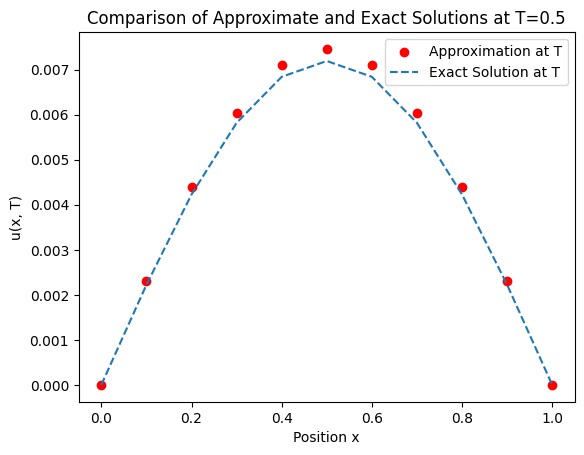

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 參數設定
L = 1          # 端點
T = 0.5        # maximum time
m = 10         # 要將Ｌ的切分數
N = 50         # 要將時間的切分數
h = L / m      # Ｌ間距
k = T / N      # 時間間距
alpha = 1      # constant
lambda1 = alpha**2 * k / h**2

# 初始條件
u_cn = np.zeros((m+1, N+1))
u_cn[:, 0] = np.sin(np.pi * np.linspace(0, L, m+1))

# 建立矩陣Ａ
diagonal = np.ones(m-1) * (1 + lambda1)
off_diagonal = np.ones(m-2) * (-lambda1 / 2)
A = np.diag(off_diagonal, -1) + np.diag(diagonal) + np.diag(off_diagonal, 1)

# Time-stepping loop
for n in range(1, N+1):
    # 用邊界條件 跟上一個解 計算向量Ｂ
    B = u_cn[0:m-1, n-1] * (lambda1 / 2) + u_cn[1:m, n-1] * (1 - lambda1) + u_cn[2:m+1, n-1] * (lambda1 / 2)
    B[0] -= u_cn[0, n] * (lambda1 / 2)
    B[-1] -= u_cn[m, n] * (lambda1 / 2)

    # 解 A * x = B
    u_cn[1:m, n] = np.linalg.solve(A, B)

# Exact solution
exact_w = np.sin(np.pi * np.linspace(0, L, m+1)) * np.exp(-(np.pi)**2 * T)

# 比較 approximation solution 和 exact solution 的圖表
comparison_table = np.vstack((np.linspace(0, L, m+1), u_cn[:, -1], exact_w)).T

# Print
print("Comparison at time T={}: ".format(T))
print("x \tApproximation \tExact")
for i, row in enumerate(comparison_table):
    print(f"{row[0]:.1f}\t{row[1]:.8f}\t{row[2]:.8f}")

# 繪圖
plt.scatter(comparison_table[:, 0], comparison_table[:, 1], color='red', label='Approximation at T')
plt.plot(comparison_table[:, 0], comparison_table[:, 2], label='Exact Solution at T', linestyle='--')
plt.xlabel('Position x')
plt.ylabel('u(x, T)')
plt.title('Comparison of Approximate and Exact Solutions at T={}'.format(T))
plt.legend()
plt.show()


答案與課本提供的是一樣的，所以我的程式碼應該沒問題

這次我要利用解 $ Aw^{j+1} = Bw^{j} $ 的方式來解這個熱方程，為了方便我將 $ Bw^{j} $ 直接變成向量，這樣有助於我去進行迭代，那中間的過程中，我有直接使用到 np.linalg.solve(A, B) 這樣的程式碼，但實際上在解這樣的方程時，如果不用這個函數庫的話，我們正確來說應該使用像是作業1 $ \text{ SOR ,Jacobi ,Gauss-Seidel } $ ,或者作業2 $ \text{ conjugate gradient} $ 解出 $ x $ 的解，並且因為矩陣式稀疏的，所以我們可以利用作業2 $ \text{ preconditioning } $ 的方式去加速 ,但我這裡都沒用的原因是因為我想把重點著重在呈現 $ Crank-Nicolson $ 的方法，因此為求程式碼簡潔的呈現該方法，因此都沒有使用上述的方式進行運算或者加速，但下面會開始使用一些上述方法來計算


# 以下是我有用 $ \text{conjugate gradient} $ 去解 $ Aw^{j+1} = Bw^{j} $ ,也是我這份作業的最終解答

Comparison at time T=1: 
x 	Approximation 	Exact
0.0	0.00000000	0.00000000
0.2	0.02673838	0.02620618
0.4	0.05085942	0.04984711
0.6	0.07000199	0.06860866
0.8	0.08229227	0.08065432
1.0	0.08652721	0.08480497
1.2	0.08229227	0.08065432
1.4	0.07000199	0.06860866
1.6	0.05085942	0.04984711
1.8	0.02673838	0.02620618
2.0	0.00000000	0.00000000


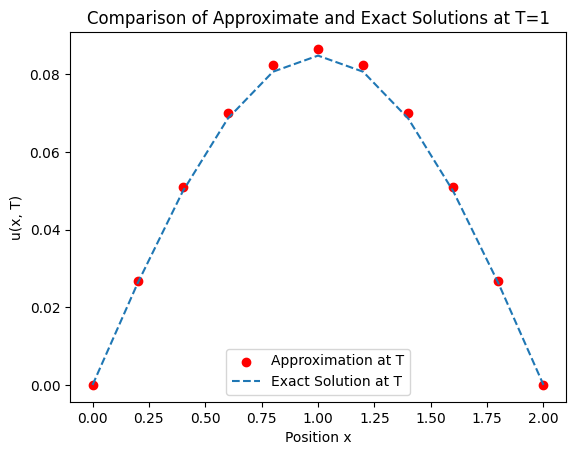

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# conjugate_gradient
def conjugate_gradient(A, b, tol=1e-10, max_iter=1000):
    x = np.zeros_like(b, dtype=np.float64)
    r = b - np.dot(A, x)
    v = r.copy()
    rdot = np.dot(r, r)

    for i in range(max_iter):
        Av = np.dot(A, v)
        t = rdot / np.dot(v, Av)
        x += t * v
        r -= t * Av
        rsnew = np.dot(r, r)
        if np.sqrt(rsnew) < tol:
            break
        v = r + (rsnew / rdot) * v
        rdot = rsnew
    return x

# 參數設定
L = 2          # 端點
T = 1          # maximum time
m = 10         # 要將Ｌ的切分數
N = 100        # 要將時間的切分數
h = L / m      # Ｌ間距
k = T / N      # 時間間距
alpha = 1      # constant
lambda1 = alpha**2 * k / h**2

# 初始條件
u_cn = np.zeros((m+1, N+1))
u_cn[:, 0] = np.sin(np.pi / 2 * np.linspace(0, L, m+1))

# 建立矩陣Ａ
diagonal = np.ones(m-1) * (1 + lambda1)
off_diagonal = np.ones(m-2) * (-lambda1 / 2)
A = np.diag(off_diagonal, -1) + np.diag(diagonal) + np.diag(off_diagonal, 1)

# Time-stepping loop
for n in range(1, N+1):
    # 用邊界條件 跟上一個解 計算向量Ｂ
    B = u_cn[0:m-1, n-1] * (lambda1 / 2) + u_cn[1:m, n-1] * (1 - lambda1) + u_cn[2:m+1, n-1] * (lambda1 / 2)
    B[0] -= u_cn[0, n] * (lambda1 / 2)
    B[-1] -= u_cn[m, n] * (lambda1 / 2)

    # 解 A * x = B
    u_cn[1:m, n] = conjugate_gradient(A, B)

# Exact solution
exact_w = np.sin(np.pi/2 * np.linspace(0, L, m+1)) * np.exp(-(np.pi/2)**2 * T)

# 比較 approximation solution 和 exact solution 的圖表
comparison_table = np.vstack((np.linspace(0, L, m+1), u_cn[:, -1], exact_w)).T

# Print
print("Comparison at time T={}: ".format(T))
print("x \tApproximation \tExact")
for i, row in enumerate(comparison_table):
    print(f"{row[0]:.1f}\t{row[1]:.8f}\t{row[2]:.8f}")

# 繪圖
plt.scatter(comparison_table[:, 0], comparison_table[:, 1], color='red', label='Approximation at T')
plt.plot(comparison_table[:, 0], comparison_table[:, 2], label='Exact Solution at T', linestyle='--')
plt.xlabel('Position x')
plt.ylabel('u(x, T)')
plt.title('Comparison of Approximate and Exact Solutions at T={}'.format(T))
plt.legend()
plt.show()


結果是一樣，看來整個程式碼沒問題，所以這才是做完整的作業解答，並且應該是沒有錯的


# 我在用課本例子檢查一次好了

Comparison at time T=0.5: 
x 	Approximation 	Exact
0.0	0.00000000	0.00000000
0.1	0.00230512	0.00222241
0.2	0.00438461	0.00422728
0.3	0.00603489	0.00581836
0.4	0.00709444	0.00683989
0.5	0.00745954	0.00719188
0.6	0.00709444	0.00683989
0.7	0.00603489	0.00581836
0.8	0.00438461	0.00422728
0.9	0.00230512	0.00222241
1.0	0.00000000	0.00000000


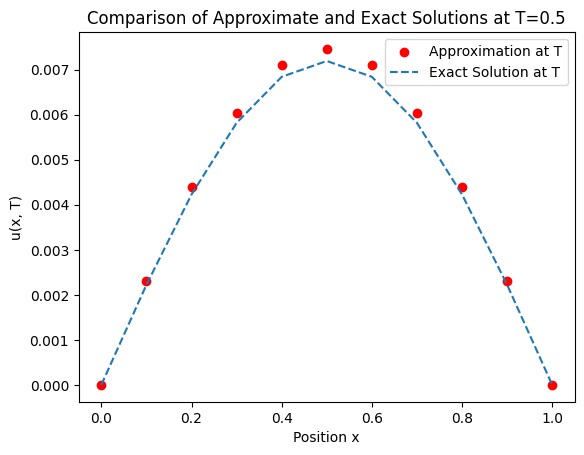

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# conjugate_gradient
def conjugate_gradient(A, b, tol=1e-10, max_iter=1000):
    x = np.zeros_like(b, dtype=np.float64)
    r = b - np.dot(A, x)
    v = r.copy()
    rdot = np.dot(r, r)

    for i in range(max_iter):
        Av = np.dot(A, v)
        t = rdot / np.dot(v, Av)
        x += t * v
        r -= t * Av
        rsnew = np.dot(r, r)
        if np.sqrt(rsnew) < tol:
            break
        v = r + (rsnew / rdot) * v
        rdot = rsnew
    return x

# 參數設定
L = 1          # 端點
T = 0.5        # maximum time
m = 10         # 要將Ｌ的切分數
N = 50         # 要將時間的切分數
h = L / m      # Ｌ間距
k = T / N      # 時間間距
alpha = 1      # constant
lambda1 = alpha**2 * k / h**2

# 初始條件
u_cn = np.zeros((m+1, N+1))
u_cn[:, 0] = np.sin(np.pi * np.linspace(0, L, m+1))

# 建立矩陣Ａ
diagonal = np.ones(m-1) * (1 + lambda1)
off_diagonal = np.ones(m-2) * (-lambda1 / 2)
A = np.diag(off_diagonal, -1) + np.diag(diagonal) + np.diag(off_diagonal, 1)

# Time-stepping loop
for n in range(1, N+1):
    # 用邊界條件 跟上一個解 計算向量Ｂ
    B = u_cn[0:m-1, n-1] * (lambda1 / 2) + u_cn[1:m, n-1] * (1 - lambda1) + u_cn[2:m+1, n-1] * (lambda1 / 2)
    B[0] -= u_cn[0, n] * (lambda1 / 2)
    B[-1] -= u_cn[m, n] * (lambda1 / 2)

    # 解 A * x = B
    u_cn[1:m, n] = conjugate_gradient(A, B)

# Exact solution
exact_w = np.sin(np.pi * np.linspace(0, L, m+1)) * np.exp(-(np.pi)**2 * T)

# 比較 approximation solution 和 exact solution 的圖表
comparison_table = np.vstack((np.linspace(0, L, m+1), u_cn[:, -1], exact_w)).T

# Print
print("Comparison at time T={}: ".format(T))
print("x \tApproximation \tExact")
for i, row in enumerate(comparison_table):
    print(f"{row[0]:.1f}\t{row[1]:.8f}\t{row[2]:.8f}")

# 繪圖
plt.scatter(comparison_table[:, 0], comparison_table[:, 1], color='red', label='Approximation at T')
plt.plot(comparison_table[:, 0], comparison_table[:, 2], label='Exact Solution at T', linestyle='--')
plt.xlabel('Position x')
plt.ylabel('u(x, T)')
plt.title('Comparison of Approximate and Exact Solutions at T={}'.format(T))
plt.legend()
plt.show()


也跟前面算出來的結果，課本的結果吻合，因此我的程式碼並沒有問題